# NeuroBridge-S4 Graph Learning — Phase 12: PyTorch Temporal Graph Autoencoder Showcase

*Self-supervised representation learning for within-subject biological adaptation trajectories.*

## 2. Plain-language purpose

This notebook adds a PyTorch self-supervised learning layer to NeuroBridge-S4. It learns compact latent representations of within-subject biological graph trajectories using reconstruction objectives. The model is a research prototype and does not make clinical, exposure, risk, or mission-readiness claims.

The main deliverable of this phase is the standalone HTML showcase at `results/html/phase12_pytorch_showcase.html`.

## 3. Why this is not “training on n=4”

> The independent subject count remains small. Phase 12 does not treat features, domains, or timepoints as independent people. Instead, it learns from structured repeated graph-derived observations within subjects. The objective is representation learning, not population-level prediction.

## 4. Scientific and operational guardrails

- not diagnosis;
- not treatment guidance;
- not health risk scoring;
- not exposure measurement;
- not mission readiness classification;
- not an operational medical decision system;
- not validated prediction;
- self-supervised representation learning only.

> Phase 12 uses PyTorch for self-supervised representation learning on structured within-subject biological graph trajectories. The model learns compact latent representations of baseline-relative trajectory patterns. It does not predict health outcomes, diagnose conditions, classify mission readiness, measure hazard exposure, or produce health risk scores.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
from IPython.display import display, HTML, Image

from neurobridge_graph import torch_dataset as td
from neurobridge_graph import torch_autoencoder as ta
from neurobridge_graph import torch_training as tt
from neurobridge_graph import torch_reporting as trep
from neurobridge_graph import torch_showcase as tshow

TABLES = REPO / 'results' / 'tables'
FIGS = REPO / 'results' / 'figures'
MODELS = REPO / 'results' / 'models'
REPORTS = REPO / 'results' / 'reports'
HTML_DIR = REPO / 'results' / 'html'
for d in (TABLES, FIGS, MODELS, REPORTS, HTML_DIR):
    d.mkdir(parents=True, exist_ok=True)
tt.set_torch_seed(42)
print('Repository:', REPO)

Repository: /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning


## 5. Load Phase 6-11 outputs

Load every available Phase 6-11 table. Missing optional tables do not fail. If the underlying data are schema-demonstration/example data, the showcase states this explicitly.

In [2]:
tables = td.load_phase12_input_tables(TABLES)
readiness = td.build_phase12_input_readiness_report(tables, TABLES)
readiness.to_csv(TABLES / 'phase12_input_readiness_check.csv', index=False)
display(readiness)

USED_FALLBACK = False
PROVENANCE = None
node = tables.get('longitudinal_node_deltas')
if node is None or node.empty:
    print('Phase 12 requires Phase 6-8 outputs. Please run the longitudinal '
          'trajectory, attribution, and reference-envelope notebooks first.')
else:
    data_types = set()
    for tbl in tables.values():
        if 'data_type' in tbl.columns:
            data_types.update(tbl['data_type'].astype(str).unique())
    if any(('schema_demonstration' in d) or ('example' in d) for d in data_types):
        PROVENANCE = ('This showcase used schema-demonstration data only. '
                      'It is not scientific evidence.')
        print('Data provenance:', PROVENANCE)

,table_name,required_or_optional,status,rows,columns,notes
0,longitudinal_node_deltas,required,available,60,12,loaded
1,longitudinal_graph_deltas,optional,available,70,10,loaded
2,longitudinal_hazard_deltas,optional,available,50,10,loaded
3,recovery_metrics,optional,available,8,11,loaded
4,trajectory_node_attribution,optional,available,60,12,loaded
5,trajectory_graph_metric_attribution,optional,available,70,12,loaded
6,trajectory_subgraph_attribution,optional,available,50,11,loaded
7,trajectory_hazard_attribution,optional,available,50,12,loaded
8,recovery_attribution,optional,available,8,10,loaded
9,reference_calibrated_node_delta_scores,optional,available,60,13,loaded


Data provenance: This showcase used schema-demonstration data only. It is not scientific evidence.


## 6. Build trajectory feature matrix

One row per graph-derived trajectory state (subject × timepoint). Feature families: domain deltas, graph-metric deltas, hazard-context deltas, attribution shares, reference-envelope counts, recovery features, and Phase 11 resilience annotations (metadata only).

In [3]:
feature_matrix, feature_catalog = td.build_trajectory_feature_matrix(tables)
feature_matrix, enc_catalog = td.encode_resilience_metadata(
    feature_matrix, tables.get('resilience_state_table'))
feature_matrix.to_csv(TABLES / 'phase12_trajectory_feature_matrix.csv', index=False)
feature_catalog.to_csv(TABLES / 'phase12_feature_catalog.csv', index=False)
print('trajectory rows:', len(feature_matrix), '| feature families:',
      sorted(feature_catalog['feature_family'].unique()) if not feature_catalog.empty else [])
display(feature_matrix.head())
display(feature_catalog.head(10))

X, feature_names = td.select_numeric_model_features(feature_matrix)
X_scaled, scaler = td.scale_model_features(X)
X_scaled.to_csv(TABLES / 'phase12_scaled_training_matrix.csv', index=False)
print('numeric model features:', len(feature_names))

trajectory rows: 10 | feature families: ['attribution_hazard', 'attribution_node', 'attribution_subgraph', 'domain_delta', 'envelope', 'graph_metric_delta', 'hazard_context_delta', 'recovery']


,trajectory_id,subject_id,timepoint,mission_phase,time_index,data_type,domain_delta__body_composition_physical_status,domain_delta__cardiovascular_regulation,domain_delta__hematologic_oxygen_carrying,domain_delta__inflammation_immune_adjacent,...,recovery_frac__mean_node_activation,recovery_frac__n_active_domains,recovery_frac__total_node_activation,recovery_finaldelta__max_node_activation,recovery_finaldelta__mean_node_activation,recovery_finaldelta__n_active_domains,recovery_finaldelta__total_node_activation,resilience_state_label,dominant_adaptation_mode,confidence_level
0,Demo_Crew_01__T0_baseline,Demo_Crew_01,T0_baseline,baseline,0,schema_demonstration_not_scientific_evidence,0.00,0.00,0.00,0.00,...,0.76824,1.0,0.76824,0.08,0.09,0.0,0.54,Stable compensated trajectory,Cardiometabolic-recovery dominant,high
1,Demo_Crew_01__T1_pre,Demo_Crew_01,T1_pre,pre_mission,1,schema_demonstration_not_scientific_evidence,0.02,0.03,0.02,0.03,...,0.76824,1.0,0.76824,0.08,0.09,0.0,0.54,Localized adaptive shift,Multi-subgraph distributed,high
2,Demo_Crew_01__T2_inflight,Demo_Crew_01,T2_inflight,inflight,2,schema_demonstration_not_scientific_evidence,0.40,0.25,0.20,0.40,...,0.76824,1.0,0.76824,0.08,0.09,0.0,0.54,Systemic strain pattern,Multi-subgraph distributed,high
3,Demo_Crew_01__T3_post,Demo_Crew_01,T3_post,postflight,3,schema_demonstration_not_scientific_evidence,0.55,0.40,0.32,0.55,...,0.76824,1.0,0.76824,0.08,0.09,0.0,0.54,Systemic strain pattern,Multi-subgraph distributed,high
4,Demo_Crew_01__T4_recovery,Demo_Crew_01,T4_recovery,recovery,4,schema_demonstration_not_scientific_evidence,0.12,0.10,0.07,0.13,...,0.76824,1.0,0.76824,0.08,0.09,0.0,0.54,Persistent displacement,Multi-subgraph distributed,high


,feature_name,source_table,feature_family,description
0,domain_delta__body_composition_physical_status,longitudinal_node_deltas,domain_delta,Baseline-relative domain activation change.
1,domain_delta__cardiovascular_regulation,longitudinal_node_deltas,domain_delta,Baseline-relative domain activation change.
2,domain_delta__hematologic_oxygen_carrying,longitudinal_node_deltas,domain_delta,Baseline-relative domain activation change.
3,domain_delta__inflammation_immune_adjacent,longitudinal_node_deltas,domain_delta,Baseline-relative domain activation change.
4,domain_delta__metabolic_regulation,longitudinal_node_deltas,domain_delta,Baseline-relative domain activation change.
5,domain_delta__recovery_related_markers,longitudinal_node_deltas,domain_delta,Baseline-relative domain activation change.
6,graph_delta__active_domain_fraction,longitudinal_graph_deltas,graph_metric_delta,Baseline-relative graph-metric change.
7,graph_delta__coactivation_edge_count,longitudinal_graph_deltas,graph_metric_delta,Baseline-relative graph-metric change.
8,graph_delta__graph_density,longitudinal_graph_deltas,graph_metric_delta,Baseline-relative graph-metric change.
9,graph_delta__max_node_activation,longitudinal_graph_deltas,graph_metric_delta,Baseline-relative graph-metric change.


numeric model features: 45


## 7. Create masked self-supervised reconstruction dataset

The model learns internal structure by reconstructing graph-derived trajectory features from a partially masked input.

In [4]:
X_masked, X_target, mask = td.create_masked_training_data(
    X_scaled, mask_fraction=0.15, random_state=42)
mask_summary = td.build_mask_summary(mask, feature_names)
mask_summary.to_csv(TABLES / 'phase12_mask_summary.csv', index=False)
display(mask_summary.head())
dataset = td.TrajectoryFeatureDataset(X_masked, X_target)
print('dataset size:', len(dataset))

,scope,name,masked_fraction,masked_count,total
0,overall,all_features,0.17778,80,450
1,feature,domain_delta__body_composition_physical_status,0.20000,2,10
2,feature,domain_delta__cardiovascular_regulation,0.20000,2,10
3,feature,domain_delta__hematologic_oxygen_carrying,0.20000,2,10
4,feature,domain_delta__inflammation_immune_adjacent,0.20000,2,10


dataset size: 10


## 8. Define the PyTorch autoencoder

A lightweight fully connected autoencoder: input → hidden (GELU + dropout) → latent bottleneck → symmetric decoder. Intentionally small to avoid overfitting a tiny dataset.

In [5]:
input_dim = len(feature_names)
latent_dim = ta.choose_latent_dim(input_dim, max_latent_dim=8)
model = ta.TrajectoryAutoencoder(input_dim=input_dim, latent_dim=latent_dim)
param_count = ta.count_trainable_parameters(model)
model_metadata = {
    'model_name': 'NeuroBridge-S4 Trajectory Autoencoder',
    'input_dim': input_dim, 'latent_dim': latent_dim,
    'hidden_dims': model.hidden_dims, 'parameter_count': param_count,
    'n_rows': len(feature_matrix), 'training_objective': 'masked MSE reconstruction',
}
model_summary = pd.DataFrame([{
    'input_dim': input_dim, 'hidden_dims': str(model.hidden_dims),
    'latent_dim': latent_dim, 'parameter_count': param_count,
    'training_objective': 'masked MSE reconstruction'}])
model_summary.to_csv(TABLES / 'phase12_model_summary.csv', index=False)
display(model_summary)

,input_dim,hidden_dims,latent_dim,parameter_count,training_objective
0,45,"[45, 22]",8,6569,masked MSE reconstruction


## 9. Train the model (CPU)

Training optimizes reconstruction only. If data are insufficient (< 3 trajectory rows or < 2 numeric features), training is skipped gracefully and the report explains why.

In [6]:
ok, reason = tt.sufficient_for_training(X_scaled)
print(reason)
if ok:
    model, training_history = tt.train_autoencoder(
        model, dataset, epochs=300, batch_size=8, learning_rate=1e-3,
        weight_decay=1e-4, verbose=True)
    training_history.to_csv(TABLES / 'phase12_training_history.csv', index=False)
    tt.save_model_state(model, MODELS / 'phase12_trajectory_autoencoder.pt', model_metadata)
    tshow.plot_training_loss_curve(training_history, FIGS / 'phase12_training_loss_curve.png')
    print('final reconstruction loss:', training_history['reconstruction_loss'].iloc[-1])
else:
    training_history = pd.DataFrame(columns=['epoch', 'reconstruction_loss'])
    tshow.plot_training_loss_curve(training_history, FIGS / 'phase12_training_loss_curve.png')

Sufficient data for self-supervised reconstruction training.
epoch    1 | reconstruction_loss 0.889819
epoch   50 | reconstruction_loss 0.372112


epoch  100 | reconstruction_loss 0.227427


epoch  150 | reconstruction_loss 0.219833
epoch  200 | reconstruction_loss 0.126620


epoch  250 | reconstruction_loss 0.094678


epoch  300 | reconstruction_loss 0.088143
final reconstruction loss: 0.08814344


## 10. Compute latent embeddings and reconstruction mismatch

Reconstruction mismatch indicates how hard a trajectory state is to reconstruct. It is a representation-quality signal, not a risk score.

In [7]:
meta_cols = [c for c in ['trajectory_id', 'subject_id', 'timepoint', 'mission_phase',
             'resilience_state_label', 'dominant_adaptation_mode', 'confidence_level']
             if c in feature_matrix.columns]
metadata_df = feature_matrix[meta_cols].copy()
embeddings_df, reconstruction_df, feature_reconstruction_df = \
    tt.compute_embeddings_and_reconstructions(model, X_scaled, metadata_df)
embeddings_df.to_csv(TABLES / 'phase12_latent_embeddings.csv', index=False)
reconstruction_df.to_csv(TABLES / 'phase12_reconstruction_errors.csv', index=False)
feature_reconstruction_df.to_csv(TABLES / 'phase12_feature_reconstruction_errors.csv', index=False)
display(reconstruction_df.head())
tshow.plot_reconstruction_error(reconstruction_df, FIGS / 'phase12_reconstruction_error.png')
tshow.plot_feature_reconstruction_error(feature_reconstruction_df, FIGS / 'phase12_feature_reconstruction_error.png')

,trajectory_id,subject_id,timepoint,mission_phase,resilience_state_label,dominant_adaptation_mode,confidence_level,reconstruction_mse,reconstruction_rmse
0,Demo_Crew_01__T0_baseline,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,Cardiometabolic-recovery dominant,high,0.024481,0.156466
1,Demo_Crew_01__T1_pre,Demo_Crew_01,T1_pre,pre_mission,Localized adaptive shift,Multi-subgraph distributed,high,0.022827,0.151087
2,Demo_Crew_01__T2_inflight,Demo_Crew_01,T2_inflight,inflight,Systemic strain pattern,Multi-subgraph distributed,high,0.073653,0.271390
3,Demo_Crew_01__T3_post,Demo_Crew_01,T3_post,postflight,Systemic strain pattern,Multi-subgraph distributed,high,0.153449,0.391726
4,Demo_Crew_01__T4_recovery,Demo_Crew_01,T4_recovery,recovery,Persistent displacement,Multi-subgraph distributed,high,0.053779,0.231902


PosixPath('/Users/rm/Desktop/NeuroBridge-S4-Graph-Learning/results/figures/phase12_feature_reconstruction_error.png')

## 11. Compute trajectory similarity

Cosine similarity over latent embeddings. This is representation similarity, not the same health state.

In [8]:
similarity_matrix = tt.compute_similarity_matrix(embeddings_df)
similarity_matrix.to_csv(TABLES / 'phase12_trajectory_similarity_matrix.csv')
tshow.plot_similarity_heatmap(similarity_matrix, FIGS / 'phase12_similarity_heatmap.png')
display(similarity_matrix.round(3))

,Demo_Crew_01__T0_baseline,Demo_Crew_01__T1_pre,Demo_Crew_01__T2_inflight,Demo_Crew_01__T3_post,Demo_Crew_01__T4_recovery,Demo_Crew_02__T0_baseline,Demo_Crew_02__T1_pre,Demo_Crew_02__T2_inflight,Demo_Crew_02__T3_post,Demo_Crew_02__T4_recovery
Demo_Crew_01__T0_baseline,1.000,0.611,-0.750,-0.830,0.528,0.891,0.147,-0.854,-0.926,0.120
Demo_Crew_01__T1_pre,0.611,1.000,-0.287,-0.416,0.968,0.202,-0.150,-0.571,-0.587,-0.259
Demo_Crew_01__T2_inflight,-0.750,-0.287,1.000,0.985,-0.097,-0.824,-0.651,0.417,0.604,-0.648
Demo_Crew_01__T3_post,-0.830,-0.416,0.985,1.000,-0.248,-0.837,-0.529,0.548,0.717,-0.517
Demo_Crew_01__T4_recovery,0.528,0.968,-0.097,-0.248,1.000,0.090,-0.386,-0.609,-0.577,-0.485
Demo_Crew_02__T0_baseline,0.891,0.202,-0.824,-0.837,0.090,1.000,0.385,-0.674,-0.776,0.405
Demo_Crew_02__T1_pre,0.147,-0.150,-0.651,-0.529,-0.386,0.385,1.000,0.343,0.151,0.990
Demo_Crew_02__T2_inflight,-0.854,-0.571,0.417,0.548,-0.609,-0.674,0.343,1.000,0.975,0.354
Demo_Crew_02__T3_post,-0.926,-0.587,0.604,0.717,-0.577,-0.776,0.151,0.975,1.000,0.162
Demo_Crew_02__T4_recovery,0.120,-0.259,-0.648,-0.517,-0.485,0.405,0.990,0.354,0.162,1.000


## 12. Visualize the latent space

A visualization of learned representation structure, not validation. Points are annotated by Phase 11 resilience state where available.

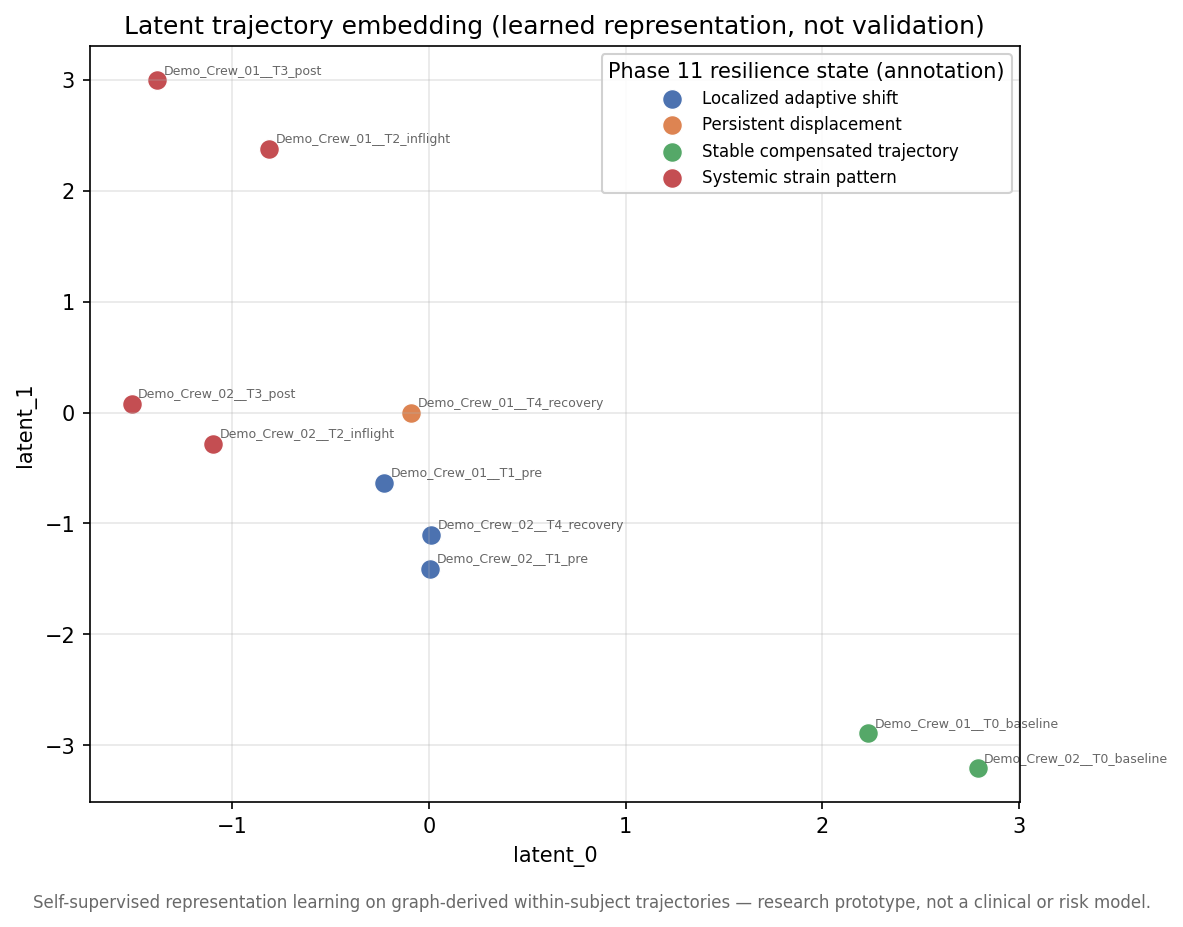

In [9]:
tshow.plot_latent_space(embeddings_df, FIGS / 'phase12_latent_space.png')
display(Image(filename=str(FIGS / 'phase12_latent_space.png')))

## 13. Link learned representations to operational resilience interpretation

If `resilience_state_table.csv` exists, compare reconstruction mismatch with Phase 11 resilience states. This is a consistency view, not validation of resilience states.

In [10]:
resilience_consistency = trep.build_resilience_consistency_view(
    embeddings_df, reconstruction_df, tables.get('resilience_state_table'))
resilience_consistency.to_csv(TABLES / 'phase12_resilience_consistency_view.csv', index=False)
tshow.plot_resilience_annotation_view(resilience_consistency, FIGS / 'phase12_resilience_annotation_view.png')
display(resilience_consistency.head(12))

,trajectory_id,subject_id,timepoint,mission_phase,resilience_state_label,dominant_adaptation_mode,reconstruction_mse,reconstruction_rmse
0,Demo_Crew_01__T0_baseline,Demo_Crew_01,T0_baseline,baseline,Stable compensated trajectory,Cardiometabolic-recovery dominant,0.024481,0.156466
1,Demo_Crew_01__T1_pre,Demo_Crew_01,T1_pre,pre_mission,Localized adaptive shift,Multi-subgraph distributed,0.022827,0.151087
2,Demo_Crew_01__T2_inflight,Demo_Crew_01,T2_inflight,inflight,Systemic strain pattern,Multi-subgraph distributed,0.073653,0.271390
3,Demo_Crew_01__T3_post,Demo_Crew_01,T3_post,postflight,Systemic strain pattern,Multi-subgraph distributed,0.153449,0.391726
4,Demo_Crew_01__T4_recovery,Demo_Crew_01,T4_recovery,recovery,Persistent displacement,Multi-subgraph distributed,0.053779,0.231902
5,Demo_Crew_02__T0_baseline,Demo_Crew_02,T0_baseline,baseline,Stable compensated trajectory,Cardiometabolic-recovery dominant,0.100737,0.317391
6,Demo_Crew_02__T1_pre,Demo_Crew_02,T1_pre,pre_mission,Localized adaptive shift,Multi-subgraph distributed,0.053893,0.232149
7,Demo_Crew_02__T2_inflight,Demo_Crew_02,T2_inflight,inflight,Systemic strain pattern,Multi-subgraph distributed,0.044547,0.211062
8,Demo_Crew_02__T3_post,Demo_Crew_02,T3_post,postflight,Systemic strain pattern,Multi-subgraph distributed,0.067510,0.259827
9,Demo_Crew_02__T4_recovery,Demo_Crew_02,T4_recovery,recovery,Localized adaptive shift,Multi-subgraph distributed,0.072019,0.268364


## 14. Generate the model card

In [11]:
model_card = trep.generate_phase12_model_card(
    model_metadata, feature_catalog, training_history, reconstruction_df,
    embeddings_df, data_provenance_note=PROVENANCE)
(REPORTS / 'phase12_model_card.md').write_text(model_card)
print(model_card[:1200])

# Phase 12 Model Card — Trajectory Autoencoder

## Model name
NeuroBridge-S4 Trajectory Autoencoder

## Model type
Fully connected self-supervised autoencoder (PyTorch). Reconstruction and masked-reconstruction objective.

## Purpose
Phase 12 uses PyTorch for self-supervised representation learning on structured within-subject biological graph trajectories. The model learns compact latent representations of baseline-relative trajectory patterns. It does not predict health outcomes, diagnose conditions, classify mission readiness, measure hazard exposure, or produce health risk scores.

## Intended use
- Research-review exploration of within-subject graph trajectory structure.
- Learning compact latent representations of baseline-relative trajectory states.
- Comparing trajectory shape similarity in latent space.
- Providing a consistency view against Phase 11 operational resilience annotations.

## Not intended use
- Not diagnosis, disease detection, or clinical decision-making.
- Not 

## 15. Generate the polished HTML showcase

This standalone page is the main portfolio artifact for Phase 12.

In [12]:
model_metadata['framing'] = trep.CORE_FRAMING
figure_paths = {
    'training_loss': str(FIGS / 'phase12_training_loss_curve.png'),
    'latent_space': str(FIGS / 'phase12_latent_space.png'),
    'reconstruction_error': str(FIGS / 'phase12_reconstruction_error.png'),
    'feature_reconstruction_error': str(FIGS / 'phase12_feature_reconstruction_error.png'),
    'similarity_heatmap': str(FIGS / 'phase12_similarity_heatmap.png'),
    'resilience_annotation_view': str(FIGS / 'phase12_resilience_annotation_view.png'),
}
html_path = tshow.create_phase12_showcase_html(
    HTML_DIR / 'phase12_pytorch_showcase.html',
    readiness_report=readiness, feature_matrix=feature_matrix,
    training_history=training_history, reconstruction_df=reconstruction_df,
    embeddings_df=embeddings_df, similarity_matrix=similarity_matrix,
    model_card_text=model_card, resilience_consistency_df=resilience_consistency,
    figure_paths=figure_paths, data_provenance_note=PROVENANCE,
    model_metadata=model_metadata)
print('HTML showcase written to:', html_path)

HTML showcase written to: /Users/rm/Desktop/NeuroBridge-S4-Graph-Learning/results/html/phase12_pytorch_showcase.html


## 16. Generate the Phase 12 report

In [13]:
report = trep.generate_phase12_showcase_report(
    readiness, feature_matrix, training_history, reconstruction_df,
    embeddings_df, data_provenance_note=PROVENANCE)
(REPORTS / 'phase12_pytorch_showcase_report.txt').write_text(report)
print(report)

NeuroBridge-S4 Graph Learning
Phase 12 — PyTorch Temporal Graph Autoencoder Showcase Report

Overview
----------------------------------------------------------------------
Phase 12 uses PyTorch for self-supervised representation learning on structured within-subject biological graph trajectories. The model learns compact latent representations of baseline-relative trajectory patterns. It does not predict health outcomes, diagnose conditions, classify mission readiness, measure hazard exposure, or produce health risk scores.

The model does not treat domains, features, or timepoints as independent people. It learns from structured repeated graph-derived observations within subjects.

Data provenance
----------------------------------------------------------------------
This showcase used schema-demonstration data only. It is not scientific evidence.

Input readiness
----------------------------------------------------------------------
- longitudinal_node_deltas [required]: available (

## 17. Conclusion

Phase 12 demonstrates that NeuroBridge-S4 can support self-supervised temporal representation learning on graph-derived within-subject trajectories. This is an experimental ML showcase and does not replace the explainable analysis pipeline.

**Next phase:** Phase 13 — Portfolio release.